# Mixture policy compression

In the previous notebook, we have observed that while action priors are powerful in explaining participants variance. However, we have also seen that Q values and action priors are not fully sufficient to explain participants behaviour, as the additional regressors from Ott's planning and hybrid model were still required to get the best fit. A possible explanation is that we have so far only considered single action priors in isolation. It is however likely that participants priors are not only defined regarding only one aspect of the task but a combination thereof. In other words, it is likely that participants consider for example both offer as well as cost to make a decision. In this notebook, we will explore this idea by devising models combining several action priors.

Just as before, following the idea that participants behaviours follows a softmax function:

$$
P(a=1|s) = \frac{\beta_1 e^{\beta Q(s,a=1) + \sum_{j=1}^{n} \theta_j log(P_j(a=i))}}{\sum_{i=1}^{k} \beta_1 e^{\beta Q(s,a=i) + \sum_{j=1}^{n} \theta_j log(P_j(a=i))}}
$$

Where $n$ is the number of distinct priors. This simplifies to:

$$
\begin{align}
P(a=1|s) &= \frac{1}{q+e^{-\eta}} \\
\eta &= \beta (Q(a=1) - Q(a=0)) + \sum_{j=1}^{n} \theta_j logit(P_j(a=1))
\end{align}
$$

We will therefore fit such mixture models, combining priors associated with offer, transition and costs that we will then compare to the fits with and without the additional regressors from Ott's original models. We will skip the energy dimension, because we saw in the previous notebook that our homeostatic prior didn't seem to be doing much. It is surely possible to find a different parametrization for it, but for now, we will stick to what works. 

# Preparing the data

In [1]:
import numpy as np
import pandas as pd
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
import arviz as az
import bambi as bmb
from scipy.special import logit


# ===================================================================
# Loading the raw data:
data = pd.read_csv("../../data/raw_data/all_participants_data.csv", on_bad_lines='skip')

# ===================================================================
# Data preprocessing:
# Remove nans:
data = data.dropna()
# Flip responses: 1 = accept:
data["response"] = np.abs(data["response"] - 1)
# Make trial 1 based
data["trial"] = data["trial"] + 1
# Generate future cost based on the transitions:
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
data["fc"] = [transitions_costs[row["transition"]][1] for _, row in data.iterrows()]

# ===================================================================
# Task MDP:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 0.99
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()

# Add decision values to the dataframe:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
data['dv'] = dv_trials

# Compute offer specific decision value regressors:
data['dv_23'] = data['dv'].to_numpy() * (data['is_2'].to_numpy() + data['is_3'].to_numpy())
data['dv_14'] = data['dv'].to_numpy() * (data['is_1'].to_numpy() + data['is_4'].to_numpy())

# Compute state dependent action priors:

In [2]:
# ===================================================================
# Coarse offers prior:
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    if o < 3:
        data.loc[trial_i, 'P(A)-offer'] = 0.25
    else:
        data.loc[trial_i, 'P(A)-offer'] = 0.75

# ===================================================================
# Costs prior
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    if cc == 1:
        data.loc[trial_i, 'P(A)-costs'] = 0.75
    elif cc == 2:
        data.loc[trial_i, 'P(A)-costs'] = 0.25

# ===================================================================
# Transition prior prior
for trial_i, trial in data.iterrows():
    transition = trial.transition
    if transition == 0 or transition == 3:
        data.loc[trial_i, 'P(A)-transition'] = 0.5
    elif transition == 1:
        data.loc[trial_i, 'P(A)-transition'] = 0.25
    elif transition == 2:
        data.loc[trial_i, 'P(A)-transition'] = 0.75

# Convert them all to logit:
data["logitP_A_offer"] = logit(data['P(A)-offer'].to_numpy())
data["logitP_A_costs"] = logit(data['P(A)-costs'].to_numpy())
data["logitP_A_transition"] = logit(data['P(A)-transition'].to_numpy())

# Model fitting:

In [ ]:
traces = {}

# ===================================================================
# Simple logistic hierarchical model (Benchmark):
logistic_model = bmb.Model(
    "response ~ dv + (dv|vpn)", 
    data, 
    family="bernoulli")
traces['logistic_model'] = logistic_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Planning model from Ott's (Benchmark)
planning_model = bmb.Model(
    "response ~ dv + is_basic + is_full_energy + is_low_energy_LC + is_low_energy_HC + "
    "(dv + is_basic|vpn)", 
    data, 
    family="bernoulli")
traces['planning_model'] = planning_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Hybrid model from Ott's (Benchmark)
hybrid_model = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + "
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model'] = hybrid_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Hybrid model with offer specific action prior (for reference from previous notebook):
hybrid_model_offer = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer +"
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_offer|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model_offer'] = hybrid_model_offer.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Hybrid model with costs specific action prior  (for reference from previous notebook):
hybrid_model_costs = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_costs +"
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_costs|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model_costs'] = hybrid_model_costs.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Hybrid model with transition specific action prior:
hybrid_model_transition = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_transition +"
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_transition|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model_transition'] = hybrid_model_transition.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Simple mixture model
prior_mixture_model = bmb.Model(
    "response ~ dv + logitP_A_offer + logitP_A_costs + logitP_A_transition + "
    "(dv + logitP_A_offer + logitP_A_costs + logitP_A_transition|vpn)", 
    data, 
    family="bernoulli")
traces['prior_mixture_model'] = prior_mixture_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Planning mixture model
planning_prior_mixture_model = bmb.Model(
    "response ~ dv + is_basic + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer + logitP_A_costs + logitP_A_transition +"
    "(dv + is_basic + logitP_A_offer + logitP_A_costs + logitP_A_transition|vpn)",
    data, 
    family="bernoulli")
traces['planning_prior_mixture_model'] = planning_prior_mixture_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Hybrid mixture model
hybrid_prior_mixture_model = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer + logitP_A_costs +  logitP_A_transition + "
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_offer + logitP_A_costs + logitP_A_transition|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_prior_mixture_model'] = hybrid_prior_mixture_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

Modeling the probability that response==1
Modeling the probability that response==1
Modeling the probability that response==1


As expected, the models using the mixture of all priors performs the best compared to models considering only 1 prior at a time. Notably however, the prior_mixture_model which consists of only the priors and the decision values and none of the additional regressors from Ott's planning and hybrid model does not perform the best. This would have been expected if the additional regressors from Ott's prior contain information that is redundant with what our priors are specifying. If we believe that the way participants solve the task so efficiently is by combining the decision values with priors, then a model containing only those should perform the best, especially because the prior_mixture_model contains fewer parameters and has hence lower complexity.

Instead, we observe that the hybrid model with the added priors performs better than the simpler models, indicating that there is some information from the additional regressors that are not found within the priors. This is to some extent to be expected, as some of those additional regressors concern energy, for which we don't have priors. But the hybrid model contains offer specific regressors. On the one hand, the parameters `dv_23` and `dv_14` separate the intermediate and extreme offers, and the `is_1`, `is_2`, `is_3`, `is_4` parameters encode offer specific pariticipants might have. Chances are, these regressors are to some extent redundant with the offer prior, so we might get a better fit by removing these parameters when adding the offer prior, essentially explaining the same variance with fewer parameters. It might at first not be obvious why these regressors might be redundant with the offer prior, the offer prior after all only distinguishes between high and low offers. However, it is important to remember that under policy compression, the prior gets combined with the decision value associated with each state. On average, the decision value associated with offer 1 will be lower than the decision value associated with offer 2, such that when combined with the same action prior, the resulting action probability will be different. It is through this combination that the offer prior could explain the same variance as the offer specific biases or also the distinction of `dv_23` and `dv_14`. 


If we remove both the `dv_23` and `dv_14` as well as the `is_1`, `is_2`, `is_3`, `is_4` parameters, we are back to the planning model, which was observed to not have as great a fit. So instead, we will remove one set of regressor or the other:

Modeling the probability that response==1
Modeling the probability that response==1
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-r

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
hybrid_prior_mixture_model,0,-1573.245214,215.014752,0.000000,0.430863,51.006780,0.000000,True,log
prior_mixture_model_offer_bias,1,-1573.577283,197.421381,0.332069,0.532053,51.118460,7.783511,True,log
prior_mixture_model_dv_bias,2,-1609.698232,186.790174,36.453018,0.037084,52.305768,10.937046,True,log


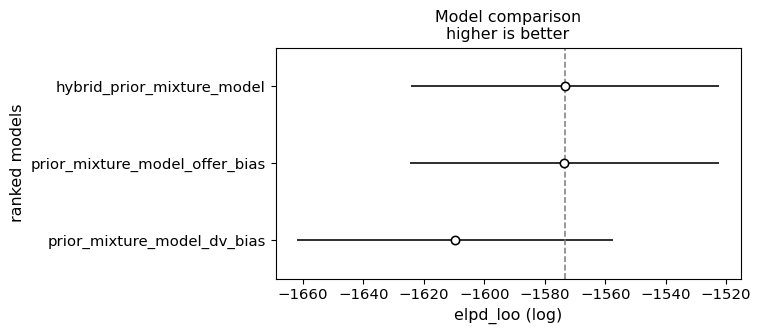

In [ ]:
# ===================================================================
# Prior mixture model without distinction between extreme and intermediate offers
prior_mixture_model_offer_bias = bmb.Model(
    "response ~ dv + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer + logitP_A_costs +  logitP_A_transition + "
    "(dv + is_1 + is_2 + is_3 + is_4 + logitP_A_offer + logitP_A_costs + logitP_A_transition|vpn)", 
    data, 
    family="bernoulli")
traces['prior_mixture_model_offer_bias'] = prior_mixture_model_offer_bias.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Prior mixture model without distinction between extreme and intermediate offers
prior_mixture_model_dv_bias = bmb.Model(
    "response ~ dv_23 + dv_14 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer + logitP_A_costs +  logitP_A_transition + "
    "(dv_23 + dv_14 + logitP_A_offer + logitP_A_costs + logitP_A_transition|vpn)", 
    data, 
    family="bernoulli")
traces['prior_mixture_model_dv_bias'] = prior_mixture_model_dv_bias.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# Compare the models:
model_comparison = az.compare({key: traces[key] for key in ["hybrid_prior_mixture_model", "prior_mixture_model_offer_bias", "prior_mixture_model_dv_bias"]})
az.plot_compare(model_comparison);
model_comparison

Unfortunately, none of these parametrization improve the fit compared to the full on hybrid model. However, removing the `dv_23` and `dv_14` doesn't significantly decreases the fit, indicating that there is perhaps some redundance between the offer prior and this split between decision values. However, the fact that the `prior_mixture_model_dv_bias` doesn't fit the data better than the `hybrid_prior_mixture_model` indicate that that's not fully the case, as it has lower complexity and should therefore improve the fit. 

In addition, it is worth noting that in the previous mopdel comparison, the `hybrid_model_transition` and `hybrid_model_costs` both ranked really close to the hybrid model with all priors combined. So perhaps, the addition of the offer prior is overkill and we would obtain a better fit by removing it, keeping only the costs and transition priors.  

Modeling the probability that response==1
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observa

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
cost_transition_hybrid_model,0,-1571.426968,211.836055,0.000000,1.000000e+00,50.879213,0.000000,True,log
hybrid_prior_mixture_model,1,-1573.245214,215.014752,1.818245,1.665335e-16,51.006780,1.323643,True,log


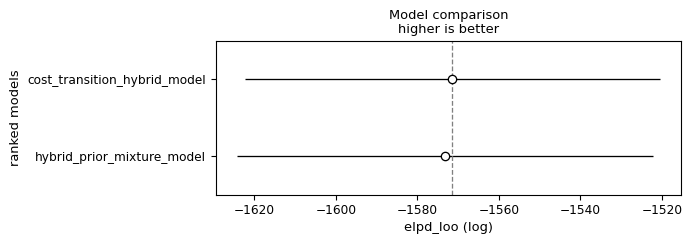

In [ ]:
# ===================================================================
# Hybrid model wiuth only costs and transition prior, no offer prior
cost_transition_hybrid_model = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_costs +  logitP_A_transition + "
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_costs + logitP_A_transition|vpn)", 
    data, 
    family="bernoulli")
traces['cost_transition_hybrid_model'] = cost_transition_hybrid_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# Compare the models:
model_comparison = az.compare({key: traces[key] for key in ["hybrid_prior_mixture_model", "cost_transition_hybrid_model"]})
az.plot_compare(model_comparison);
model_comparison

These results indicate that we get a similar fit with and without the offer prior when using the hybrid model. This is a bit puzzling: if the offer prior really didn't explain any variance, the fit should actually be better when omitting it because once again the model is less complex. The fact that it doesn't indicate that there is definitely something about the offer prior that is not completely redundant with the additional regressors, but it's not quite clear what that could be. 

In any case, we can now dig into the parameters estimation from the hybrid model with all the priors.

In [ ]:
import matplotlib.pyplot as plt
az.plot_trace(traces["hybrid_prior_mixture_model"], 
              var_names=["dv_23", "dv_14", "is_1", "is_2", "is_3", "is_4", 
                         "is_full_energy", "is_low_energy_LC", "is_low_energy_HC", 
                         "logitP_A_offer", "logitP_A_costs", "logitP_A_transition"], 
              combined=True)
plt.tight_layout()

KeyError: 'var names: "[\'1|logitP_A_transition\'] are not present" in dataset'

These results indicate that participants upweight the decision values by a larger amount in the intermediate compared to the extreme offers. They also exhibit offer specific biases such that they gradually downweight the low offers and gradually upweight the large offers. When it comes to the energy edge cases (max energy and too low energy) is that they are overly liberal when their energy is max (i.e. have a tendency to accept offers more than they should), and are overly conservative in the low energy cases. The latter is perhaps a bit odd, they should always reject when the energy is too low, but these are relative terms given that they get summed with all the other. Finally, when it comes to the priors, they do indeed follow the costs and transition prior. However, for hte transition prior, the negative weight indicate that they behave in the opposite direction than we believed, they tend to accept offers a bit more when the current cost is high and future cost is low, and the opposite when the current cost is high and the future cost is low. This wasn't what we had expected, but I suppose that this is also a reasonable thing to do: when the current cost is high but the future cost is low, participants might consider that if a large offer comes up, it's fine loosing energy over it, given that in the future segment, just rejecting an offer will put them in a position where they can accept an offer again, and vice versa. In fact, when looking at the single participants fits, we can see that some participants seem to fit what we expected, while others do the opposite. 

# Discussion

Overall, these results are a bit puzzling. Eventhough the hybrid model combined with all the prior perfoms the best, there are many other parametrization that perform equally well. What seems to be happening is that the offer prior is to some extent redundant with some of the regressors from the hybrid model, though not fully. This suggests that the specific offer specific action prior that the participants rely on is a bit different from the one we have selected.

In any case, the ultimate goal, or intuition that we have is that participants decision is the result of the combination between some sort of value maximizing action values (we have used the exact Q function obtained through backward induction, but it is likely that participant use a different more tractable algorithm to approximate it) and some priors over action derived from previous experience with similar situations and problems. If that is the case, then a model with only these two components should be able to outperform the hybrid model and its somewhat arbitrary additional regressors. The fact that this has not been the case so far might indicate that the priors we have selected so far are not the right ones, which might very well be the case.

But an alternative idea is that the shortcomings of the simpler model containing only decision values and the action priors might reflect the fact that our action priors remain fixed throughout the experiment. However, a key component of the policy compression is that the marginal action probability is not fixed but rather dynamically changes as a function of the actions taken during a task. In each state, participants' actions are the result of the weighted sum between the decision values associated with that state and the action prior. If the decision values are close to 0 for that state, then the prior takes the lead, such that over time, the marginal probability of accepting in that state remains the same. In contrast, if the decision values are really large, they might outweight the action prior in a given trial. As this gets repeated, the prior, which depends on how often a particular action was taken in the past, will shift towards the action probability associated with the decision value. This is what we will explore in the next notebook. 